# 17 - Task 3: tuning LightGBM on the raw-text features

**The last untouched axis.** Task 3 sits at 0.80143 and everything that produced it is
settled: notebook 14 chose the representation, notebook 16 mapped the per-group share
surface to its vertices. But **the shipped model is LightGBM at default hyperparameters.**
Every search in this repo ran against the supplied 5,000 TF-IDF columns; nothing has been
tuned on 40,385 raw-text columns, which is a different problem in shape - far wider, far
sparser, and three quarters character n-grams.

It is also the only axis left that **can be validated locally.** Predicted share needs a
Kaggle slot to measure; hyperparameters can be scored against the grouped protocol that
has been tracking transfer all round.

| baseline | Macro F1 |
|---|---|
| standard 5-fold CV | 0.8764 |
| leave-one-length-band-out (3 bands) | 0.8089 |

**Honest expectation: 0 to +0.01 on grouped CV, less on Kaggle.** Tuning this same model
family on the supplied features moved CV from 0.7391 to 0.7443, about +0.005. LightGBM
defaults are strong and this is a well-conditioned problem. A null is a likely outcome and
section 9 says how to report it.

---

## The problem this notebook is designed around

Five people at three hours each will produce **250 or more configs**. Selecting the
argmax over that many trials, scored on folds whose spread is 0.087, fits validation noise
almost by construction. Four guards:

1. **Paired per-fold comparison.** Band difficulty is common to every config and cancels
   in a paired difference, so compare `score_config[f] - score_base[f]` fold by fold
   instead of comparing means.
2. **Five length bands, not three.** More paired folds is better resolution and 3,200 rows
   per band is still ample.
3. **Consistency, not just the mean.** A config must improve on *every* fold and clear
   twice its paired standard error.
4. **Pick a region, then a point.** Refine around the centroid of the passing configs
   rather than shipping the single best, and confirm the winner on the **3-band** protocol
   that selection never saw.

More people makes guard 4 matter more, not less: a wider search finds a higher maximum
whether or not a real optimum exists, so the confirmation step is what keeps the extra
compute honest.

## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats as st
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.model_selection import ParameterSampler, cross_val_score
from lightgbm import LGBMClassifier

from src import paths, data, evaluation, tuning, ensemble, text, clustering
from src import text_features as tf
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Features, the locked split, and the two grouped protocols

`CHOSEN` is notebook 14's selection, the representation behind 0.80143. Nothing about it
changes here; only the estimator's hyperparameters do.

Two protocols, used for different jobs:

- **5 bands** for *selecting*, because five paired folds resolve more than three.
- **3 bands** for *confirming*, because it is the protocol notebooks 15 and 16 used and
  the search will not have selected on it.

In [2]:
train_ids, train_texts, y = text.load_train_text()
test_ids, test_texts = text.load_test_text()

dev_idx = np.load(paths.DATA_PROCESSED / "dev_idx.npy")
y_dev = y[dev_idx]
dev_texts = np.asarray(train_texts)[dev_idx]

CHOSEN = ["A_function_words", "B_punctuation", "C_casing", "D_structure",
          "E_length", "F_diversity", "H_char_ngrams", "I_word_ngrams"]
built = tf.load_blocks(CHOSEN)
X_dev = tf.stack(built, CHOSEN)[0][dev_idx]
assert X_dev.shape == (16000, 40385), X_dev.shape

folds5, skipped5 = clustering.cluster_cv(
    clustering.length_groups(dev_texts, n_groups=5), y_dev)
folds3, skipped3 = clustering.cluster_cv(
    clustering.length_groups(dev_texts, n_groups=3), y_dev)
cv_standard = evaluation.make_cv()

print(f"dev {X_dev.shape}, machine share {y_dev.mean():.4f}\n")
print(f"selection protocol: {len(folds5)} bands")
for i, (tr, te) in enumerate(folds5):
    lens = np.array([len(t) for t in dev_texts[te]])
    print(f"  band {i}: held out {len(te):5d}  machine share {y_dev[te].mean():.3f}  "
          f"chars {lens.min():5d}-{lens.max():6d}")
assert len(folds5) == 5, "a band was skipped - see skipped5"
print(f"\nconfirmation protocol: {len(folds3)} bands")
for frame in (skipped5, skipped3):
    if len(frame):
        print(frame.to_string(index=False))

dev (16000, 40385), machine share 0.6252

selection protocol: 5 bands
  band 0: held out  3198  machine share 0.567  chars    27-   387
  band 1: held out  3194  machine share 0.603  chars   388-   916
  band 2: held out  3204  machine share 0.616  chars   917-  1382
  band 3: held out  3202  machine share 0.684  chars  1383-  2188
  band 4: held out  3202  machine share 0.656  chars  2189- 17436

confirmation protocol: 3 bands


## 2. Search space - what each knob does and why this range

Fixed throughout: `class_weight="balanced"`, `random_state=42`, `n_jobs=-1`,
`verbose=-1`, and `subsample_freq=1`.

| knob | range | why this range |
|---|---|---|
| `learning_rate` | log-uniform 0.01 to 0.15 | traded against `n_estimators`; low and slow is the usual optimum on sparse text |
| `n_estimators` | 200 to 1500 | |
| `num_leaves` | 15 to 255 | LightGBM's real capacity knob, more so than depth |
| `max_depth` | -1, or 4 to 12 | interacts with `num_leaves`; -1 lets leaves bind alone |
| `min_child_samples` | 5 to 120 | the strongest regulariser against noisy sparse columns |
| `colsample_bytree` | 0.1 to 0.9 | **most likely to matter.** 20,000 of the columns are character n-grams that are zero for most documents |
| `subsample` | 0.5 to 1.0 | row bagging. **Inert unless `subsample_freq >= 1`**, which is why the freq is pinned rather than sampled |
| `reg_alpha`, `reg_lambda` | log-uniform 1e-3 to 20 | L1 drives feature selection at this width, L2 smooths |

**A hypothesis, stated now and answered in section 7.** Under domain shift the grouped
optimum should sit at *stronger* regularisation than a standard-CV optimum would: lower
`num_leaves`, higher `min_child_samples`, lower `colsample_bytree`. Section 7 scores the
winner under both protocols so this is settled by measurement.

In [3]:
SPACE = {
    "learning_rate":     st.loguniform(0.01, 0.15),
    "n_estimators":      st.randint(200, 1501),
    "num_leaves":        st.randint(15, 256),
    "max_depth":         [-1, 4, 6, 8, 10, 12],
    "min_child_samples": st.randint(5, 121),
    "colsample_bytree":  st.uniform(0.10, 0.80),   # 0.10 to 0.90
    "subsample":         st.uniform(0.50, 0.50),   # 0.50 to 1.00
    "reg_alpha":         st.loguniform(1e-3, 20),
    "reg_lambda":        st.loguniform(1e-3, 20),
}

FIXED = dict(class_weight="balanced", subsample_freq=1, random_state=42,
             n_jobs=-1, verbose=-1)


def build_estimator(params):
    '''params -> a fresh LGBMClassifier. run_trial never calls set_params itself.'''
    return LGBMClassifier(**params, **FIXED)


# One shared, seeded list so all four members generate exactly the same configs and the
# stride slices below partition it. 400 is deliberate over-supply: the wall-clock budget
# is what stops the search, not the sampler.
CONFIGS = list(ParameterSampler(SPACE, n_iter=400, random_state=42))
print(f"{len(CONFIGS)} shared configs")
print(json.dumps({k: (round(v, 5) if isinstance(v, float) else v)
                  for k, v in CONFIGS[0].items()}, indent=2))

400 shared configs
{
  "colsample_bytree": 0.39963,
  "learning_rate": 0.13126,
  "max_depth": 6,
  "min_child_samples": 76,
  "n_estimators": 1244,
  "num_leaves": 117,
  "reg_alpha": 0.08271,
  "reg_lambda": 0.00269,
  "subsample": 0.72962
}


## 3. Reference points: defaults, and the supplied-feature winner

Two configs everyone runs, so the paired comparison has a per-fold reference and so the
two problems can be compared directly.

`data/processed/best_lightgbm_params.json` is the winner from tuning this same model on
the **supplied 5,000 TF-IDF features**. Whether it transfers to a 40,385-column raw-text
matrix is worth one trial and is interesting either way.

Duplicates across members are harmless: `run_trial` keys the cache on the parameters and
the owner is pinned to `"shared"`, so every member writes the same filename with the same
content and section 5 dedupes on the parameters regardless.

In [4]:
# LightGBM defaults, i.e. the model behind 0.80143. FIXED adds subsample_freq=1, which
# is inert while subsample stays at its default 1.0, so this is the same estimator.
DEFAULTS = {}

prior = json.loads((paths.DATA_PROCESSED / "best_lightgbm_params.json").read_text())
# That search predates max_depth and subsample being in the space; fill them with the
# values it effectively used so the parameter dict is comparable to CONFIGS entries.
PRIOR = {**prior, "max_depth": -1, "subsample": 1.0}

STAGE1 = "lgbm_text_stage1"

base_rec = tuning.run_trial(STAGE1, "shared", build_estimator(DEFAULTS), DEFAULTS,
                            X_dev, y_dev, folds5)
prior_rec = tuning.run_trial(STAGE1, "shared", build_estimator(PRIOR), PRIOR,
                             X_dev, y_dev, folds5)

BASE = np.array(base_rec["scores"])
print(f"defaults        grouped(5) {base_rec['mean']:.4f}  folds {np.round(BASE, 4).tolist()}")
print(f"supplied-winner grouped(5) {prior_rec['mean']:.4f}  "
      f"paired {np.mean(np.array(prior_rec['scores']) - BASE):+.4f}")

defaults        grouped(5) 0.8077  folds [0.6266, 0.7915, 0.8766, 0.9073, 0.8364]
supplied-winner grouped(5) 0.8121  paired +0.0044


## 4. Stage 1 - the coarse search

**Change `ME` and nothing else.**

| member | slice | configs |
|---|---|---|
| cliffton | `CONFIGS[0::5]` | 80 |
| koko | `CONFIGS[1::5]` | 80 |
| jovyan | `CONFIGS[2::5]` | 80 |
| brian | `CONFIGS[3::5]` | 80 |
| vincent | `CONFIGS[4::5]` | 80 |

The shared config list is sliced by stride, so every member's slice is still a uniform
random sample of the space. Carving the space into five regions instead would make each
member's table biased and the merged table not a random search.

The stride comes from `len(MEMBERS)`, so a sixth person is one entry in that list and
nothing else; the cell asserts the slices still partition the config list exactly.

`run_search` writes each trial the moment it finishes and stops on a wall-clock cap, so an
interrupted run loses nothing, a slow machine simply contributes fewer trials, and
re-running after a `git pull` skips whatever teammates already covered.

In [5]:
MEMBERS = ["cliffton", "koko", "jovyan", "brian", "vincent"]
N = len(MEMBERS)       # everything below derives from this, so adding a sixth member
                       # is one entry in this list and nothing else

ME = "jovyan"        # <-- THE ONLY LINE TO CHANGE

BUDGET_SECONDS = 12 * 3600

assert ME in MEMBERS, f"{ME!r} is not in MEMBERS - add the name before running"
idx = MEMBERS.index(ME)
MY_CONFIGS = CONFIGS[idx::N]

# The slices must partition the list exactly: no config run twice, none missed. Asserted
# rather than assumed because a stride left over from a different member count would
# silently duplicate some configs and skip others.
covered = sorted(j for m in range(N) for j in range(m, len(CONFIGS), N))
assert covered == list(range(len(CONFIGS))), "stride slices do not partition CONFIGS"
sizes = {len(CONFIGS[m::N]) for m in range(N)}
assert max(sizes) - min(sizes) <= 1, f"slices are unbalanced: {sorted(sizes)}"

print(f"{N} members, {len(CONFIGS)} shared configs, {sorted(sizes)} per slice")
print(f"{ME} runs {len(MY_CONFIGS)} of them "
      f"(budget {BUDGET_SECONDS / 3600:.0f}h, whichever comes first)")

5 members, 400 shared configs, [80] per slice
jovyan runs 80 of them (budget 12h, whichever comes first)


In [6]:
run = tuning.run_search(STAGE1, ME, build_estimator, MY_CONFIGS,
                        X_dev, y_dev, folds5, budget_seconds=BUDGET_SECONDS)
print(f"\n{len(run)} trials this run")
if len(run):
    print(run.head(5)[["mean", "std"]].round(4).to_string())

[1] mean=0.7979 std=0.1022  (0s, 0.0/720 min, 5123097 trials/hr)
[2] mean=0.8091 std=0.1038  (0s, 0.0/720 min, 4708036 trials/hr)
[3] mean=0.8086 std=0.1012  (0s, 0.0/720 min, 5252663 trials/hr)
[4] mean=0.8062 std=0.1109  (0s, 0.0/720 min, 5681370 trials/hr)
[5] mean=0.7922 std=0.1094  (0s, 0.0/720 min, 5814141 trials/hr)
[6] mean=0.8155 std=0.0996  (0s, 0.0/720 min, 6183442 trials/hr)
[7] mean=0.8052 std=0.1045  (0s, 0.0/720 min, 6480815 trials/hr)
[8] mean=0.8036 std=0.1046  (0s, 0.0/720 min, 6643139 trials/hr)
[9] mean=0.7983 std=0.1103  (0s, 0.0/720 min, 6883073 trials/hr)
[10] mean=0.7930 std=0.1107  (0s, 0.0/720 min, 7065889 trials/hr)


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

[11] mean=0.8191 std=0.0995  (1930s, 32.2/720 min, 21 trials/hr)


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

[12] mean=0.8090 std=0.1069  (1059s, 49.8/720 min, 14 trials/hr)


...

[30] mean=0.8050 std=0.1066  (2694s, 600.2/720 min, 3 trials/hr)


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

[31] mean=0.8000 std=0.1018  (1555s, 626.1/720 min, 3 trials/hr)


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


KeyboardInterrupt: 

### Commit your trials

```bash
git add data/processed/tuning_trials/
git commit -m "feat: lgbm text-feature tuning stage 1 for <your name>"
git push
```

Section 5 needs everyone's, so `git pull` first.

## 5. Merge, and the paired analysis

Raw means are the wrong comparison here. The five bands differ in difficulty by far more
than any two configs differ from each other, and that difficulty is **common to every
config**, so it cancels in a paired difference. Comparing means instead of pairs is what
made round 6's bar so conservative that nothing could clear it.

| column | meaning |
|---|---|
| `paired_mean` | mean over folds of `score - defaults` |
| `paired_se` | `std(diff, ddof=1) / sqrt(n_folds)` |
| `folds_better` | how many of the five folds improved |
| `passes` | `paired_mean > 2 * paired_se` **and** `folds_better == 5` |

In [19]:
trials = tuning.load_trials(STAGE1)
trials["key"] = trials["params"].apply(tuning.trial_id)
trials = trials.drop_duplicates("key").reset_index(drop=True)
print(f"{len(trials)} unique configs from {trials['owner'].nunique()} owners")
print(trials["owner"].value_counts().to_string())

diffs = trials["scores"].apply(lambda s: np.array(s) - BASE)
trials["paired_mean"] = diffs.apply(np.mean)
trials["paired_se"] = diffs.apply(
    lambda d: float(np.std(d, ddof=1) / np.sqrt(len(d))) if len(d) > 1 else np.nan)
trials["folds_better"] = diffs.apply(lambda d: int((d > 0).sum()))
trials["passes"] = ((trials["paired_mean"] > 2 * trials["paired_se"])
                    & (trials["folds_better"] == len(BASE)))

ranked = trials.sort_values("paired_mean", ascending=False)
print(f"\n{int(trials['passes'].sum())} of {len(trials)} configs pass\n")
print(ranked.head(10)[["owner", "mean", "paired_mean", "paired_se",
                       "folds_better", "passes"]].round(4).to_string(index=False))

60 unique configs from 4 owners
owner
cliffton    48
brian        6
jovyan       4
shared       2

3 of 60 configs pass

   owner   mean  paired_mean  paired_se  folds_better  passes
cliffton 0.8192       0.0115     0.0042             5    True
cliffton 0.8186       0.0108     0.0056             4   False
cliffton 0.8169       0.0092     0.0049             4   False
cliffton 0.8166       0.0089     0.0053             4   False
cliffton 0.8166       0.0089     0.0038             4   False
cliffton 0.8165       0.0088     0.0073             4   False
cliffton 0.8153       0.0076     0.0074             4   False
cliffton 0.8152       0.0075     0.0029             5    True
cliffton 0.8142       0.0065     0.0015             5    True
   brian 0.8142       0.0065     0.0059             3   False


### Split-half stability: did the search resolve anything?

Rank the configs using bands {0,1,2}, rank them again using bands {3,4}, and correlate.

This is the direct measurement of the overfitting risk rather than a warning about it. A
high correlation means the ordering is real and the winner means something. A low one
means the protocol cannot separate this many configs, and the honest conclusion is
"**this region is fine**" rather than "this config is best" - in which case section 6
should refine around the region and ignore the argmax entirely.

split-half Spearman rho = 0.560  (p = 3.3e-06) over 60 configs
Ordering is reproducible across disjoint folds - the winner is meaningful.


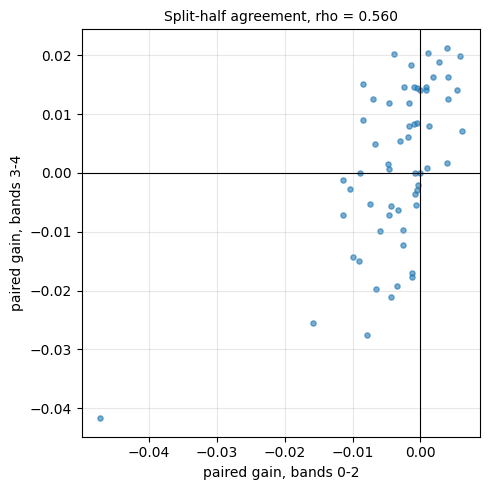

In [20]:
half_a = trials["scores"].apply(lambda s: float(np.mean(np.array(s)[:3] - BASE[:3])))
half_b = trials["scores"].apply(lambda s: float(np.mean(np.array(s)[3:] - BASE[3:])))
rho, pval = spearmanr(half_a, half_b)
print(f"split-half Spearman rho = {rho:.3f}  (p = {pval:.2g}) over {len(trials)} configs")

if rho > 0.5:
    print("Ordering is reproducible across disjoint folds - the winner is meaningful.")
elif rho > 0.2:
    print("Weak but positive - trust the REGION, treat the exact argmax as arbitrary.")
else:
    print("No reproducible ordering. The search located noise; do not ship an argmax. "
          "Report that hyperparameters do not matter measurably on this representation.")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(half_a, half_b, s=14, alpha=0.6)
ax.axhline(0, color="k", lw=0.8); ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("paired gain, bands 0-2"); ax.set_ylabel("paired gain, bands 3-4")
ax.set_title(f"Split-half agreement, rho = {rho:.3f}", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES / "tuning_split_half.png", dpi=120); plt.show()

## 6. Stage 2 - refine around the region, not the point

The centroid of the passing configs is a more robust target than the single best trial,
for the reason section 5's correlation quantifies. If nothing passes, this falls back to
the top ten by `paired_mean` and says so.

In [21]:
pool = trials[trials["passes"]] if trials["passes"].any() else ranked.head(10)
if not trials["passes"].any():
    print("Nothing passed the bar; refining around the top 10 by paired_mean instead.\n")

grid = pd.DataFrame(list(pool["params"]))
centre = {}
for c in grid.columns:
    if c == "max_depth":
        # Categorical: -1 means "unlimited", so a median across a mix of -1 and 4..12
        # would invent a depth nobody sampled. Take the most common value instead.
        centre[c] = int(grid[c].mode().iloc[0])
    elif grid[c].dtype.kind == "f":
        centre[c] = float(grid[c].median())
    else:
        centre[c] = int(np.median(grid[c]))
print(f"centroid of {len(pool)} configs:")
print(json.dumps(centre, indent=2))
print("\nspread within the pool (IQR):")
print(grid.describe().loc[["25%", "50%", "75%"]].round(4).to_string())

centroid of 3 configs:
{
  "colsample_bytree": 0.5790923731908288,
  "learning_rate": 0.06563424391407212,
  "max_depth": -1,
  "min_child_samples": 70,
  "n_estimators": 881,
  "num_leaves": 59,
  "reg_alpha": 0.05533299556768178,
  "reg_lambda": 0.1379149768296685,
  "subsample": 0.8601012908161478
}

spread within the pool (IQR):
     colsample_bytree  learning_rate  max_depth  min_child_samples  n_estimators  num_leaves  reg_alpha  reg_lambda  subsample
25%            0.5514         0.0391        3.5               56.0         557.0        45.0     0.0370      0.0704     0.7942
50%            0.5791         0.0656        8.0               70.0         881.0        59.0     0.0553      0.1379     0.8601
75%            0.5887         0.0783        9.0               85.0         982.0        83.5     0.1334      0.3447     0.8616


In [22]:
STAGE2 = "lgbm_text_stage2"


def around(v, lo, hi, frac=0.35, integer=False):
    '''A tight range around v, clipped to the stage-1 bounds.'''
    a, b = max(lo, v * (1 - frac)), min(hi, v * (1 + frac))
    return st.randint(int(a), max(int(b), int(a) + 1)) if integer else st.uniform(a, b - a)


SPACE2 = {
    "learning_rate":     around(centre["learning_rate"], 0.01, 0.15),
    "n_estimators":      around(centre["n_estimators"], 200, 1500, integer=True),
    "num_leaves":        around(centre["num_leaves"], 15, 255, integer=True),
    "max_depth":         [centre["max_depth"]],
    "min_child_samples": around(centre["min_child_samples"], 5, 120, integer=True),
    "colsample_bytree":  around(centre["colsample_bytree"], 0.10, 0.90),
    "subsample":         around(centre["subsample"], 0.50, 1.00),
    "reg_alpha":         around(centre["reg_alpha"], 1e-3, 20),
    "reg_lambda":        around(centre["reg_lambda"], 1e-3, 20),
}

# The centroid itself is run by every member, so it exists in the ledger regardless of
# who finishes; the sampled neighbourhood is sliced the same way as stage 1.
tuning.run_trial(STAGE2, "shared", build_estimator(centre), centre,
                 X_dev, y_dev, folds5)

CONFIGS2 = list(ParameterSampler(SPACE2, n_iter=120, random_state=42))
run2 = tuning.run_search(STAGE2, ME, build_estimator, CONFIGS2[idx::N],
                         X_dev, y_dev, folds5, budget_seconds=3600)
print(f"\n{len(run2)} stage-2 trials this run")

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

[1] mean=0.8009 std=0.1046  (1720s, 28.7/60 min, 2 trials/hr)


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

[2] mean=0.8165 std=0.1047  (2640s, 72.7/60 min, 2 trials/hr)

Budget reached after 72.7 min (2 trials this run) - stopping before trial 3.

2 stage-2 trials this run


In [23]:
t2 = tuning.load_trials(STAGE2)
t2["key"] = t2["params"].apply(tuning.trial_id)
t2 = t2.drop_duplicates("key").reset_index(drop=True)

d2 = t2["scores"].apply(lambda s: np.array(s) - BASE)
t2["paired_mean"] = d2.apply(np.mean)
t2["paired_se"] = d2.apply(lambda d: float(np.std(d, ddof=1) / np.sqrt(len(d))))
t2["folds_better"] = d2.apply(lambda d: int((d > 0).sum()))

both = pd.concat([trials.assign(stage=1), t2.assign(stage=2)], ignore_index=True)
best = both.sort_values("paired_mean", ascending=False).iloc[0]
BEST_PARAMS = dict(best["params"])
print(f"best overall: stage {best['stage']}, paired {best['paired_mean']:+.4f} "
      f"+/- {best['paired_se']:.4f}, better on {best['folds_better']}/{len(BASE)} folds")
print(json.dumps({k: (round(v, 5) if isinstance(v, float) else v)
                  for k, v in BEST_PARAMS.items()}, indent=2))

best overall: stage 1, paired +0.0115 +/- 0.0042, better on 5/5 folds
{
  "colsample_bytree": 0.57909,
  "learning_rate": 0.06563,
  "max_depth": 8,
  "min_child_samples": 70,
  "n_estimators": 881,
  "num_leaves": 59,
  "reg_alpha": 0.01869,
  "reg_lambda": 0.00284,
  "subsample": 0.72827
}


## 7. Confirm out of selection

The search optimised the 5-band protocol, so its own number for the winner is optimistic.
Two checks it did not select on:

- **3-band grouped CV**, the protocol from notebooks 15 and 16. A winner that gains on
  5 bands and not on 3 was fitted to the folds and is rejected.
- **Standard 5-fold CV**, which gives `transfer_gap` and answers section 2's hypothesis
  about whether the grouped optimum is more heavily regularised.

In [24]:
def score_folds(estimator, folds):
    return np.array([evaluation.macro_f1(
        y_dev[te], clone(estimator).fit(X_dev[tr], y_dev[tr]).predict(X_dev[te]))
        for tr, te in folds])


rows = []
for tag, params in [("defaults", DEFAULTS), ("tuned", BEST_PARAMS)]:
    g3 = score_folds(build_estimator(params), folds3)
    std5 = cross_val_score(build_estimator(params), X_dev, y_dev, cv=cv_standard,
                           scoring="f1_macro", n_jobs=1)
    rows.append({"model": tag, "cv_standard": round(float(std5.mean()), 4),
                 "grouped_3band": round(float(g3.mean()), 4),
                 "transfer_gap": round(float(std5.mean() - g3.mean()), 4)})
    print(f"{tag:9s} standard {std5.mean():.4f}  3-band {g3.mean():.4f}", flush=True)

confirm = pd.DataFrame(rows)
print()
print(confirm.to_string(index=False))

d_std = confirm.loc[1, "cv_standard"] - confirm.loc[0, "cv_standard"]
d_grp = confirm.loc[1, "grouped_3band"] - confirm.loc[0, "grouped_3band"]
print(f"\ntuned minus defaults:  standard {d_std:+.4f}   3-band {d_grp:+.4f}")
print("Baselines to reproduce: defaults should be 0.8764 standard / 0.8089 3-band.")

CONFIRMED = d_grp > 0
print("\nCONFIRMED out of selection" if CONFIRMED else
      "\nNOT CONFIRMED - the gain was specific to the 5-band folds. Ship the defaults.")

print("\nSection 2 hypothesis (grouped optimum should be more regularised):")
for k in ["num_leaves", "min_child_samples", "colsample_bytree", "reg_alpha",
          "reg_lambda"]:
    print(f"  {k:20s} tuned {BEST_PARAMS.get(k)}")

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

defaults  standard 0.8764  3-band 0.8089


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid featur

tuned     standard 0.8842  3-band 0.8064

   model  cv_standard  grouped_3band  transfer_gap
defaults       0.8764         0.8089        0.0675
   tuned       0.8842         0.8064        0.0778

tuned minus defaults:  standard +0.0078   3-band -0.0025
Baselines to reproduce: defaults should be 0.8764 standard / 0.8089 3-band.

NOT CONFIRMED - the gain was specific to the 5-band folds. Ship the defaults.

Section 2 hypothesis (grouped optimum should be more regularised):
  num_leaves           tuned 59
  min_child_samples    tuned 70
  colsample_bytree     tuned 0.5790923731908288
  reg_alpha            tuned 0.018686559606120094
  reg_lambda           tuned 0.002842719285873684


## 8. Refit and the scored comparison

The winner refitted on all 20,000 rows and thresholded with the **locked** per-group
shares from notebook 16, uuid 0.6198 and numeric 0.4756. Share is held identical to the
0.80143 submission so the only variable is the hyperparameters.

In [25]:
BEST_SHARES = {"uuid": 0.6198, "numeric": 0.4756}
BENCH_FILE, BENCH_F1 = "chosen_pergroup62_48.csv", 0.80143

if not CONFIRMED:
    print("Winner not confirmed in section 7. Not writing a submission.")
else:
    X_full, Xte, _ = tf.stack(built, CHOSEN)
    model = build_estimator(BEST_PARAMS).fit(X_full, y)
    scores = ensemble.member_score(model, Xte)

    groups = text.id_group(test_ids)
    masks = text.group_masks(test_ids)
    preds = clustering.threshold_per_group(scores, groups, BEST_SHARES)
    fname = "tuned_lgbm_pergroup.csv"
    data.write_submission(test_ids, preds, fname)

    sample = pd.read_csv(paths.DATA_RAW / "sample_submission.csv", dtype={"id": str})
    sub = pd.read_csv(paths.SUBMISSIONS / fname, dtype={"id": str})
    assert list(sub.columns) == ["id", "label"], sub.columns
    assert list(sub["id"]) == list(sample["id"]), "id order drifted"
    assert set(sub["label"].unique()) <= {0, 1}
    lab = sub["label"].to_numpy()
    for g, m in masks.items():
        assert abs(lab[m].mean() - BEST_SHARES[g]) < 1 / m.sum(), f"{g} share off target"

    bench = pd.read_csv(paths.SUBMISSIONS / BENCH_FILE,
                        dtype={"id": str})["label"].to_numpy()
    n_diff = int((lab != bench).sum())
    print(f"{fname}: share {lab.mean():.4f}, {n_diff} of {len(lab)} rows differ "
          f"from {BENCH_FILE} ({BENCH_F1})")
    if n_diff < 100:
        print("UNDER-POWERED: too few rows differ to resolve against the 0.0084 floor. "
              "Do not spend a slot on this.")

    json.dump({"params": BEST_PARAMS, "shares": BEST_SHARES,
               "grouped_3band": confirm.loc[1, "grouped_3band"],
               "cv_standard": confirm.loc[1, "cv_standard"], "rows_vs_bench": n_diff},
              open(paths.DATA_PROCESSED / "best_lgbm_text_params.json", "w"), indent=2)

Winner not confirmed in section 7. Not writing a submission.


## 9. Discussion / carry-forward -> Task 4 report

_Fill in once stage 2 and section 7 have run._

**Report the split-half correlation first.** It decides how everything else should be
read, and it is the number a reader needs to judge whether a 200-config search on a
3,200-row-per-band protocol found anything real.

**Then, in order:**

1. **Did anything pass?** `paired_mean > 2 x paired_se` and better on all five folds.
   Report the count out of the total, not just the winner.
2. **Did it confirm on the 3-band protocol?** The number that matters. A gain on the
   selection protocol alone is a fold artifact and section 7 rejects it.
3. **Was the grouped optimum more regularised than defaults?** That was section 2's
   hypothesis. Compare `num_leaves`, `min_child_samples` and `colsample_bytree` against
   LightGBM's defaults of 31, 20 and 1.0, and against the supplied-feature winner's 149,
   7 and 0.52. Whichever way it lands it is a reportable observation about what domain
   shift does to model selection.
4. **Did the supplied-feature winner transfer?** Its paired score is in section 3. Two
   different feature spaces, same model family, same task.

**If nothing passes and nothing confirms, that is the result.** LightGBM defaults are
already at the optimum for this representation, the last untouched axis is closed, and
what remains is the report and the final-pick selection. Do not lower the bar to find a
winner; round 6 set the precedent for reporting a null properly, and this project's
credibility in the write-up rests on having done that consistently.

**Carry-forward regardless of outcome:**

- The paired-difference method belongs in the report as a methodological note. Round 6
  compared raw means against a fold standard deviation of 0.087 and concluded nothing
  could clear it; on a protocol whose folds differ that much by design, pairing is the
  correct comparison and the earlier bar was too conservative. Blocks J and K are worth
  re-reading under it, though their gains were small enough that the verdict is unlikely
  to change.
- **Final picks.** Notebook 16 section 4 sets the rule: pair the best public point with a
  more central one rather than taking the top two public scores, because seven share
  submissions have been fitted to a leaderboard with a 0.0084 noise floor.